# Model Evaluation
## Technical Performance Metrics
### Evaluate metrics

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
models = {
    "Naive": "Naive_b3f191c11061425ea0cae3ff8faf9433.csv",
    "Seasonal_Naive": "Seasonal_Naive_d923a8d200f24477bf19d261c178bd91.csv",
    "ARIMA": "ARIMA_ffa2015860444a69a30035a209ef93ae.csv",
    "SARIMA": "SARIMA_1e20f2493b3b4e76aef3735e9293ff42.csv",
    "ARIMAX_No_New_Flags": "ARIMAX_No_New_Flags_7347b06dabc14d0bab5d94ef0f86a426.csv",
    "SARIMAX_No_New_Flags": "SARIMAX_No_New_Flags_ec295857407545cfafa0ead460d6cbb4.csv",
    "ARIMAX_Full": "ARIMAX_Full_0362ef43a9e840ccbb84a095494c78f1.csv",
    "SARIMAX_Full": "SARIMAX_Full_4bd78cf7453b4e219b8a1454084d160e.csv"
}
dfs = []
for model, file in models.items():
    df = pd.read_csv(f"../artifacts/metrics/{file}")
    df = df.rename(columns={model: "value"})
    df["model"] = model
    dfs.append(df)
metrics_df = pd.concat(dfs, ignore_index=True)

#### Average Metrics by Model

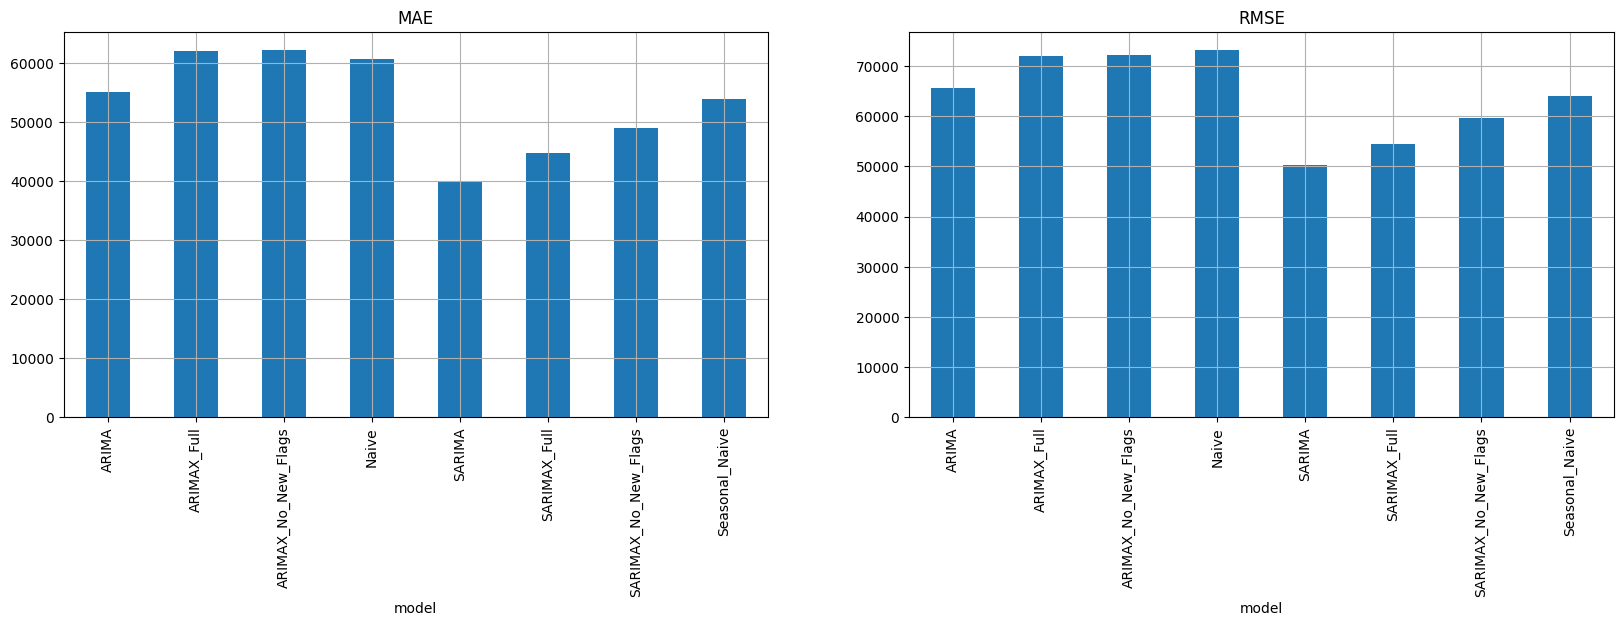

model                 metric
ARIMA                 mae       55105.187867
                      rmse      65726.549122
ARIMAX_Full           mae       62142.676616
                      rmse      71964.093657
ARIMAX_No_New_Flags   mae       62238.232005
                      rmse      72213.892087
Naive                 mae       60763.000488
                      rmse      73194.876808
SARIMA                mae       39870.870536
                      rmse      50355.782798
SARIMAX_Full          mae       44882.729328
                      rmse      54490.037804
SARIMAX_No_New_Flags  mae       49093.399159
                      rmse      59709.704046
Seasonal_Naive        mae       53936.254383
                      rmse      64120.495638
Name: value, dtype: float64


<Figure size 640x480 with 0 Axes>

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))
metrics_df[metrics_df["metric"] == "mae"].groupby("model")["value"].mean().plot(kind="bar", ax=axes[0], title="MAE")
metrics_df[metrics_df["metric"] == "rmse"].groupby("model")["value"].mean().plot(kind="bar", ax=axes[1], title="RMSE")
axes[0].grid()
axes[1].grid()
plt.show();
plt.suptitle("Average Metrics by model")
print(metrics_df.groupby(["model", "metric"])["value"].mean())


`SARIMA` is the best average model, with a MAE of 39870 USD and RMSE of 50355 USD. 

While baseline models outperform `SARIMA` for some stores, they do not consistently do so across all series. Some ARIMA-based models fail to learly capture certain time series patterns, likely due to insufficient data rather than an issue with the models themselves.

#### Best Model metrics for Store

In [20]:
metrics_mean = (
    metrics_df
    .groupby(["unique_id", "model", "metric"], as_index=False)["value"]
    .mean()
)
best_mae = (
    metrics_mean[metrics_mean["metric"] == "mae"]
    .sort_values("value")
    .drop_duplicates("unique_id", keep="first")
    .sort_values("model")
).reset_index(drop=True)
best_rmse = (
    metrics_mean[metrics_mean["metric"] == "rmse"]
    .sort_values("value")
    .drop_duplicates("unique_id", keep="first")
    .sort_values("model")
).reset_index(drop=True)

print(f"Best models, mae: {best_mae['value'].mean()}", f"rmse: {best_rmse['value'].mean()}")
best_mae["model"].value_counts()

Best models, mae: 31266.672962079145 rmse: 39977.48604805987


model
SARIMA                  26
ARIMA                    5
SARIMAX_No_New_Flags     5
Seasonal_Naive           5
ARIMAX_Full              1
ARIMAX_No_New_Flags      1
Naive                    1
SARIMAX_Full             1
Name: count, dtype: int64

Considering the best model for each store, the metrics values decrease considerably, with a MAE of 31266 USD and an RMSE of 39977 USD much better than the SARIMA average metrics.
SARIMA and ARIMA are the most frequently selected best models, performing optimally for 31 stores.

#### SARIMA and ARIMA metrics  for Store

In [16]:
metrics_mean = (
    metrics_df[metrics_df["model"].isin(["ARIMA", "SARIMA"])]
    .groupby(["unique_id", "model", "metric"], as_index=False)["value"]
    .mean()
)
best_mae = (
    metrics_mean[metrics_mean["metric"] == "mae"]
    .sort_values("value")
    .drop_duplicates("unique_id", keep="first")
    .sort_values("model")
    .reset_index(drop=True)
)

best_rmse = (
    metrics_mean[metrics_mean["metric"] == "rmse"]
    .sort_values("value")
    .drop_duplicates("unique_id", keep="first")
    .sort_values("model")
    .reset_index(drop=True)
)

print(  f"ARIMA and SARIMA mae: {best_mae['value'].mean()}",
        f"rmse: {best_rmse['value'].mean()}")
print("ARIMA stores: ",sorted(best_mae[best_mae['model']=='ARIMA']['unique_id'].unique()))
print("SARIMA stores: ",sorted(best_mae[best_mae['model']=='SARIMA']['unique_id'].unique()))


ARIMA and SARIMA mae: 33562.063355274135 rmse: 42512.9784885911
ARIMA stores:  [4, 7, 14, 16, 18, 30, 33, 36, 38, 42, 44]
SARIMA stores:  [1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 13, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 37, 39, 40, 41, 43, 45]


Filtering models to only SARIMA and ARIMA slightly worsens the performance, increasing MAE from 31266 USD to 33562 USD and RMSE from 39977 USD to 42512 USD.

However, this still outperforms the average metrics of all other models shown in the previous Average Metrics by Model plot.

Stores used for ARIMA model were 4, 7, 14, 16, 18, 30, 33, 36, 38, 42, 44.
Stores used for SARIMA model were 1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 13, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 37, 39, 40, 41, 43, 45.

### Evaluate Generalization

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

arima_stores = [4, 7, 14, 16, 18, 30, 33, 36, 38, 42, 44]

df = pd.read_csv(f"../artifacts/cv_predictions/ARIMA_ffa2015860444a69a30035a209ef93ae.csv")
df["model"] = "ARIMA"
df = df.rename(columns={"ARIMA": "value"})
df = df[df["unique_id"].isin(arima_stores)]

df2 = pd.read_csv(f"../artifacts/cv_predictions/SARIMA_1e20f2493b3b4e76aef3735e9293ff42.csv")
df2["model"] = "SARIMA"
df2 = df2.rename(columns={"SARIMA": "value"})
df2 = df2[~df2["unique_id"].isin(arima_stores)]
predictions_df = pd.concat([df, df2], ignore_index=True)

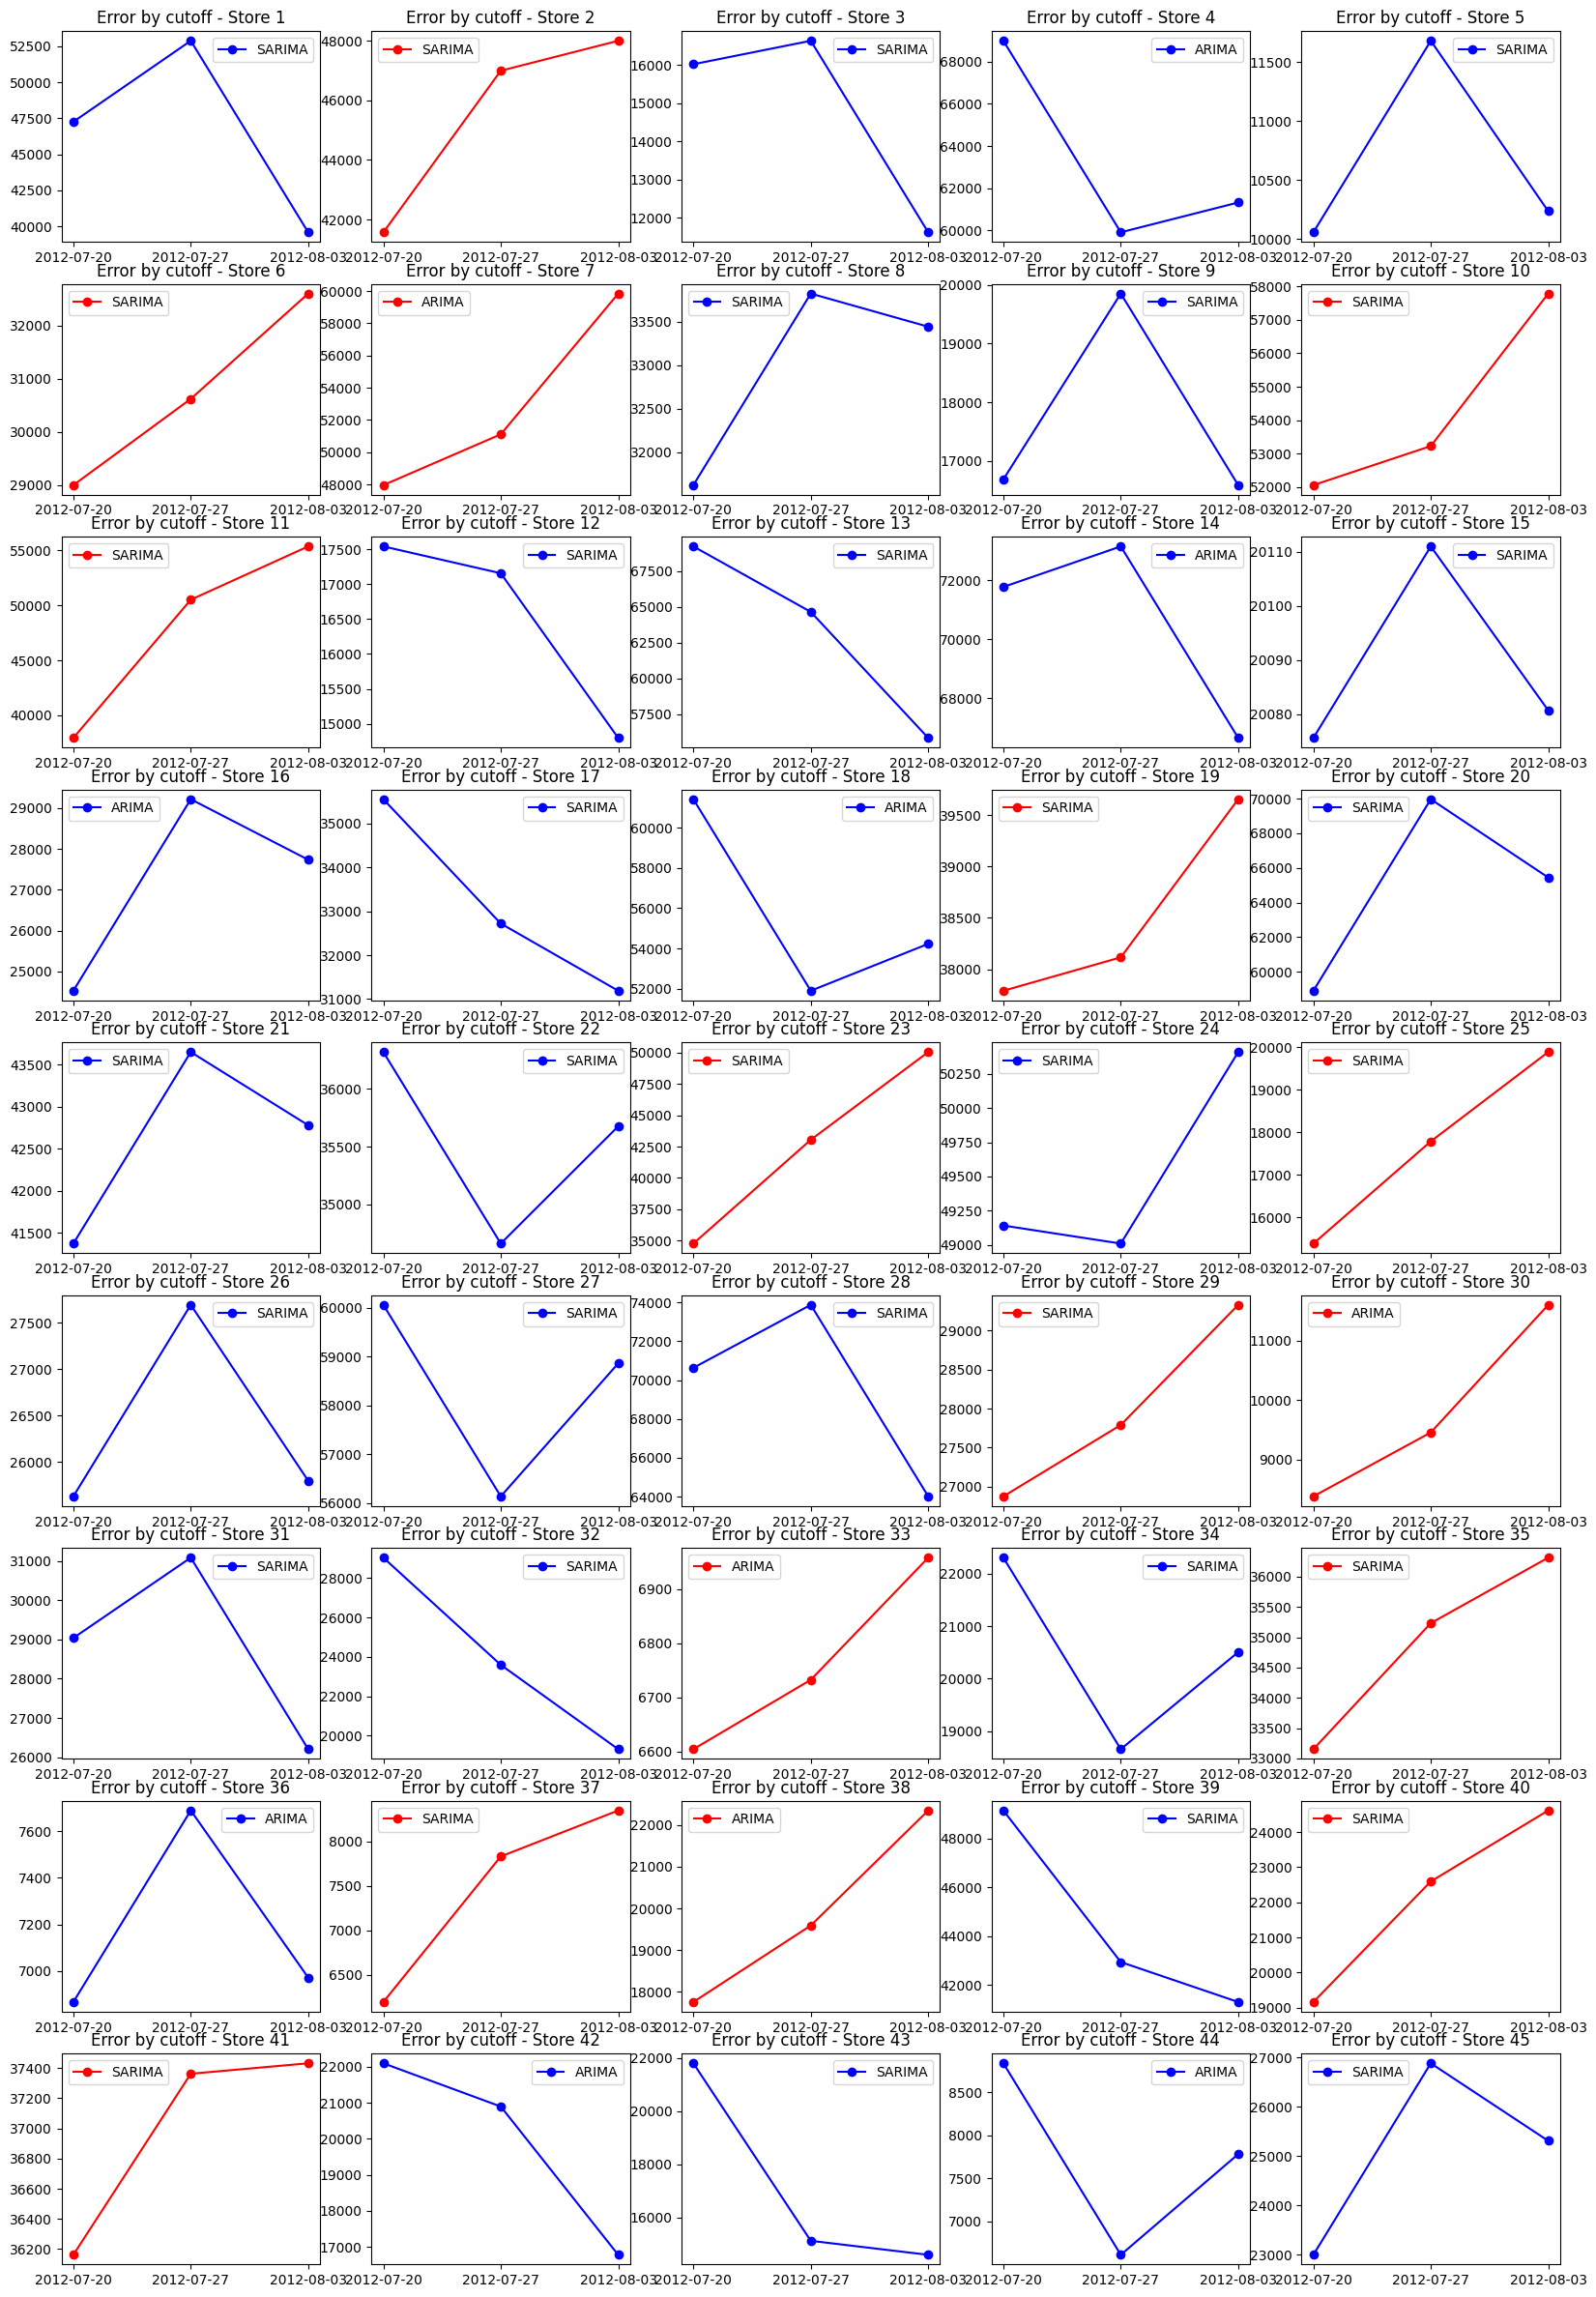

In [34]:
predictions_df['abs_error'] = abs(
    predictions_df['y'] - predictions_df['value']
)

err_store_cutoff = (
    predictions_df
    .groupby(['model', 'unique_id', 'cutoff'])['abs_error']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(9, 5, figsize=(20, 30))
axes = axes.flatten()
for idx, i in enumerate(range(1, 46)):
    ax = axes[idx]
    df_store = err_store_cutoff[err_store_cutoff['unique_id'] == i]
    for model, df_model in df_store.groupby('model'):
        is_increasing = (
            df_model['abs_error'].diff().dropna() > 0
        ).all()

        color = 'red' if is_increasing else 'blue'
        ax.plot(df_model['cutoff'], df_model['abs_error'], marker='o', label=model, color=color)
    ax.set_title(f"Error by cutoff - Store {i}")
    ax.legend()

Store error per cutoff shows some slight variability when generalizing across cutoffs. The variation between cutoffs remains around 10000 USD, which is small compared to the ARIMA and SARIMA models' average MAE of approximately 33562 USD. The model demonstrates moderate generalization capability.

## Business Metrics

The business metrics defined during the Business Uderstanding phase focus on reducing forecasting error compared to a previously used model, whose performance metrics are unkown. Improving forecast accuracy is expected to support better planning processes and enable more effective operational and financial decision-making.

However, direct validation of business impact such as improvements in operational efficiency or financial performance is not feasible due to there is not access to the business.

## Deciding on Go/No-Go for Deployment

The final decision is primarily based on technical performance metrics due to limited access to business metrics and operational data. 

The best average model across stores was SARIMA. The best-performing configuration by store correspond to a combination of all candidate models. However, when restrinting the selection to ARIMA and SARIMA models only, performance remined close to the best model combination.

Although the best-performing combinations included all available models, this introduces additional maintenance complexity and operational overhead. For this reason, ARIMA and SARIMA models were selected as the final candidates.

Some technical limitations should be considered. Certain metrics indicate minor performance challenges, possibly related to limited data availability. Additionally, the lack of access to business operations prevents direct validation of business KIPs and real-world impact. Despite these constraints, the project will proceed to deployment while explicitily acknowledging these limitations and associated risks.